# 📈 Evaluación del Modelo de Uplift

## Objetivo

Evaluar formalmente la calidad del modelo de uplift utilizando métricas adecuadas para problemas de impacto incremental.

## Por qué este notebook es importante

En problemas de uplift, métricas tradicionales como AUC, accuracy o recall no son suficientes para medir el valor real del modelo.

Aquí se evaluará si el ranking generado por el modelo realmente prioriza a los clientes con mayor efecto incremental esperado.

## Métricas principales

- Curva de uplift
- Curva Qini
- Uplift AUC
- Qini AUC
- Uplift observado por proporción de targeting

## Meta

Validar si el modelo de uplift supera al baseline tradicional cuando el objetivo es optimizar decisiones de targeting.

In [69]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklift.metrics import uplift_curve, qini_curve, uplift_auc_score, qini_auc_score

import warnings
warnings.filterwarnings('ignore')

In [70]:
ruta_uplift = r"C:\Users\sebas\OneDrive\Desktop\Proyecto Chatbot\Opti-Correos\uplift_resultados_test.csv"
ruta_baseline = r"C:\Users\sebas\OneDrive\Desktop\Proyecto Chatbot\Opti-Correos\baseline_resultados_test.csv"

df_uplift = pd.read_csv(ruta_uplift)
df_baseline = pd.read_csv(ruta_baseline)

In [71]:
print(df_uplift.shape)
print(df_baseline.shape)

(19200, 16)
(19200, 12)


In [72]:
df_uplift.head()

,id_cliente,recency,history_segment,history,mens,womens,zip_code,newbie,channel,tratamiento,target,prob_tratado,prob_control,uplift_estimado,decil_uplift,segmento_uplift
0,472,1,1) $0 - $100,79.50,0,1,Surburban,0,Web,0,0,0.431216,0.001891,0.429325,1,Persuadables
1,132,11,1) $0 - $100,52.08,0,1,Urban,0,Web,1,0,0.284483,0.000041,0.284442,1,Persuadables
2,710,9,1) $0 - $100,35.40,0,1,Surburban,1,Web,0,0,0.269170,0.000009,0.269161,1,Persuadables
3,607,11,1) $0 - $100,43.51,0,1,Surburban,0,Web,0,0,0.247792,0.000069,0.247723,1,Persuadables
4,50281,12,4) $350 - $500,441.56,1,0,Surburban,0,Web,0,0,0.231612,0.000201,0.231411,1,Persuadables


In [73]:
df_baseline.head()

,id_cliente,recency,history_segment,history,mens,womens,zip_code,newbie,channel,tratamiento,target,probabilidad
0,33042,9,1) $0 - $100,64.85,1,0,Surburban,1,Web,1,0,0.000194
1,7209,1,2) $100 - $200,144.12,0,1,Urban,0,Web,1,0,0.000484
2,24367,1,5) $500 - $750,734.25,0,1,Surburban,1,Phone,1,0,0.000422
3,19599,4,"7) $1,000 +",1321.26,1,0,Surburban,1,Multichannel,1,0,0.000342
4,31465,2,3) $200 - $350,261.23,1,1,Surburban,1,Web,1,0,0.000212


In [74]:
print(df_uplift.columns.tolist())
print(df_baseline.columns.tolist())

['id_cliente', 'recency', 'history_segment', 'history', 'mens', 'womens', 'zip_code', 'newbie', 'channel', 'tratamiento', 'target', 'prob_tratado', 'prob_control', 'uplift_estimado', 'decil_uplift', 'segmento_uplift']
['id_cliente', 'recency', 'history_segment', 'history', 'mens', 'womens', 'zip_code', 'newbie', 'channel', 'tratamiento', 'target', 'probabilidad']


In [75]:
df_comparado = df_uplift.merge(
    df_baseline[['id_cliente', 'probabilidad']],
    on='id_cliente',
    how='inner'
)

In [76]:
print(df_comparado.shape)
df_comparado.head()

(5774, 17)


,id_cliente,recency,history_segment,history,mens,womens,zip_code,newbie,channel,tratamiento,target,prob_tratado,prob_control,uplift_estimado,decil_uplift,segmento_uplift,probabilidad
0,710,9,1) $0 - $100,35.40,0,1,Surburban,1,Web,0,0,0.269170,0.000009,0.269161,1,Persuadables,0.000349
1,2325,1,"7) $1,000 +",1249.70,1,1,Surburban,1,Multichannel,1,0,0.232918,0.002475,0.230443,1,Persuadables,0.000308
2,49,10,1) $0 - $100,61.09,0,1,Surburban,0,Web,1,0,0.185974,0.000108,0.185866,1,Persuadables,0.000310
3,890,10,2) $100 - $200,167.85,0,1,Surburban,0,Web,1,0,0.170296,0.000020,0.170276,1,Persuadables,0.000279
4,39172,1,"7) $1,000 +",1447.55,1,1,Urban,1,Web,1,0,0.168711,0.003466,0.165245,1,Persuadables,0.000177


In [77]:
columnas_necesarias = [
    'id_cliente',
    'target',
    'tratamiento',
    'uplift_estimado',
    'probabilidad'
]

faltantes = [col for col in columnas_necesarias if col not in df_comparado.columns]
print("Columnas faltantes:", faltantes)

Columnas faltantes: []


In [78]:
df_comparado[columnas_necesarias].isnull().sum()

id_cliente         0
target             0
tratamiento        0
uplift_estimado    0
probabilidad       0
dtype: int64

In [79]:
y_true = df_comparado['target'].values
w = df_comparado['tratamiento'].values

score_uplift = df_comparado['uplift_estimado'].values
score_baseline = df_comparado['probabilidad'].values

In [80]:
x_uplift, y_uplift = uplift_curve(
    y_true=y_true,
    uplift=score_uplift,
    treatment=w
)

In [81]:
x_base, y_base = uplift_curve(
    y_true=y_true,
    uplift=score_baseline,
    treatment=w
)

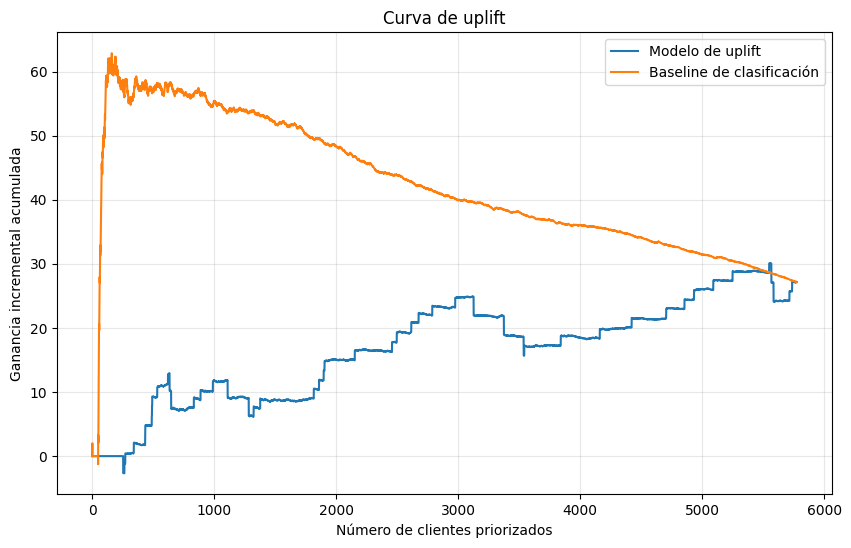

In [82]:
plt.figure(figsize=(10, 6))
plt.plot(x_uplift, y_uplift, label='Modelo de uplift')
plt.plot(x_base, y_base, label='Baseline de clasificación')
plt.title('Curva de uplift')
plt.xlabel('Número de clientes priorizados')
plt.ylabel('Ganancia incremental acumulada')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [83]:
x_qini_uplift, y_qini_uplift = qini_curve(
    y_true=y_true,
    uplift=score_uplift,
    treatment=w
)

In [84]:
x_qini_base, y_qini_base = qini_curve(
    y_true=y_true,
    uplift=score_baseline,
    treatment=w
)

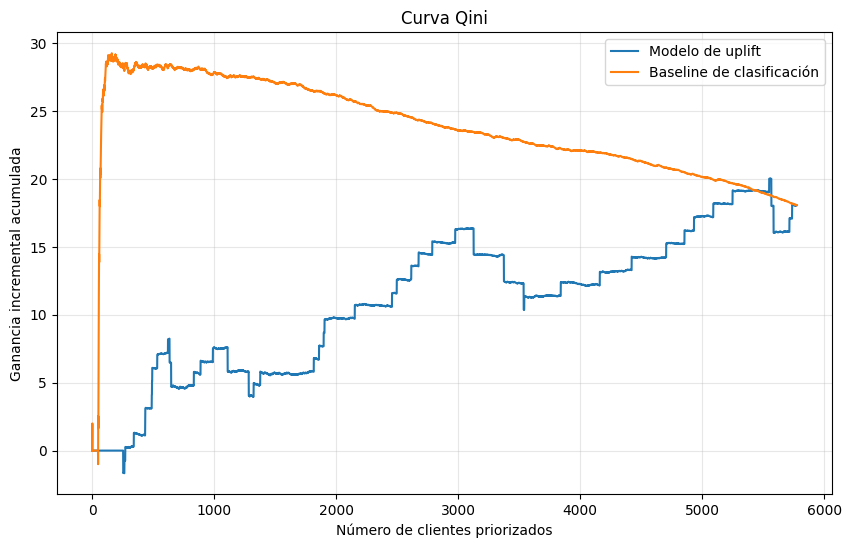

In [85]:
plt.figure(figsize=(10, 6))
plt.plot(x_qini_uplift, y_qini_uplift, label='Modelo de uplift')
plt.plot(x_qini_base, y_qini_base, label='Baseline de clasificación')
plt.title('Curva Qini')
plt.xlabel('Número de clientes priorizados')
plt.ylabel('Ganancia incremental acumulada')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [86]:
uplift_auc_modelo = uplift_auc_score(
    y_true=y_true,
    uplift=score_uplift,
    treatment=w
)

uplift_auc_baseline = uplift_auc_score(
    y_true=y_true,
    uplift=score_baseline,
    treatment=w
)

print("Uplift AUC - modelo uplift:", round(uplift_auc_modelo, 2))
print("Uplift AUC - baseline:", round(uplift_auc_baseline, 2))

Uplift AUC - modelo uplift: 0.0
Uplift AUC - baseline: 0.03


In [87]:
qini_modelo = qini_auc_score(
    y_true=y_true,
    uplift=score_uplift,
    treatment=w
)

qini_baseline = qini_auc_score(
    y_true=y_true,
    uplift=score_baseline,
    treatment=w
)

print("Qini AUC - modelo uplift:", round(qini_modelo, 2))
print("Qini AUC - baseline:", round(qini_baseline, 2))

Qini AUC - modelo uplift: 0.07
Qini AUC - baseline: 0.51


In [88]:
def uplift_observado_top(df, columna_score, proporcion):
    n = int(len(df) * proporcion)
    
    df_top = df.sort_values(by=columna_score, ascending=False).head(n).copy()
    
    conversion_tratados = df_top.loc[df_top['tratamiento'] == 1, 'target'].mean()
    conversion_control = df_top.loc[df_top['tratamiento'] == 0, 'target'].mean()
    
    uplift_obs = conversion_tratados - conversion_control
    
    return {
        'proporcion': round(proporcion, 2),
        'clientes': n,
        'conversion_tratados': round(conversion_tratados, 2),
        'conversion_control': round(conversion_control, 2),
        'uplift_observado': round(uplift_obs, 2)
    }

In [89]:
proporciones = [0.1, 0.2, 0.3, 0.5, 1.0]

In [90]:
resultados_top_uplift = pd.DataFrame([
    uplift_observado_top(df_comparado, 'uplift_estimado', p)
    for p in proporciones
])

resultados_top_uplift

,proporcion,clientes,conversion_tratados,conversion_control,uplift_observado
0,0.1,577,0.02,0.00,0.02
1,0.2,1154,0.02,0.01,0.01
2,0.3,1732,0.01,0.01,0.01
3,0.5,2887,0.01,0.01,0.01
4,1.0,5774,0.01,0.01,0.00


In [91]:
resultados_top_baseline = pd.DataFrame([
    uplift_observado_top(df_comparado, 'probabilidad', p)
    for p in proporciones
])

resultados_top_baseline

,proporcion,clientes,conversion_tratados,conversion_control,uplift_observado
0,0.1,577,0.13,0.03,0.10
1,0.2,1154,0.06,0.02,0.05
2,0.3,1732,0.04,0.01,0.03
3,0.5,2887,0.02,0.01,0.01
4,1.0,5774,0.01,0.01,0.00


In [92]:
comparacion_targeting = resultados_top_uplift.merge(
    resultados_top_baseline,
    on='proporcion',
    suffixes=('_uplift', '_baseline')
)

comparacion_targeting

,proporcion,clientes_uplift,conversion_tratados_uplift,conversion_control_uplift,uplift_observado_uplift,clientes_baseline,conversion_tratados_baseline,conversion_control_baseline,uplift_observado_baseline
0,0.1,577,0.02,0.00,0.02,577,0.13,0.03,0.10
1,0.2,1154,0.02,0.01,0.01,1154,0.06,0.02,0.05
2,0.3,1732,0.01,0.01,0.01,1732,0.04,0.01,0.03
3,0.5,2887,0.01,0.01,0.01,2887,0.02,0.01,0.01
4,1.0,5774,0.01,0.01,0.00,5774,0.01,0.01,0.00


In [93]:
comparacion_targeting = resultados_top_uplift.merge(
    resultados_top_baseline,
    on='proporcion',
    suffixes=('_uplift', '_baseline')
)

comparacion_targeting

,proporcion,clientes_uplift,conversion_tratados_uplift,conversion_control_uplift,uplift_observado_uplift,clientes_baseline,conversion_tratados_baseline,conversion_control_baseline,uplift_observado_baseline
0,0.1,577,0.02,0.00,0.02,577,0.13,0.03,0.10
1,0.2,1154,0.02,0.01,0.01,1154,0.06,0.02,0.05
2,0.3,1732,0.01,0.01,0.01,1732,0.04,0.01,0.03
3,0.5,2887,0.01,0.01,0.01,2887,0.02,0.01,0.01
4,1.0,5774,0.01,0.01,0.00,5774,0.01,0.01,0.00


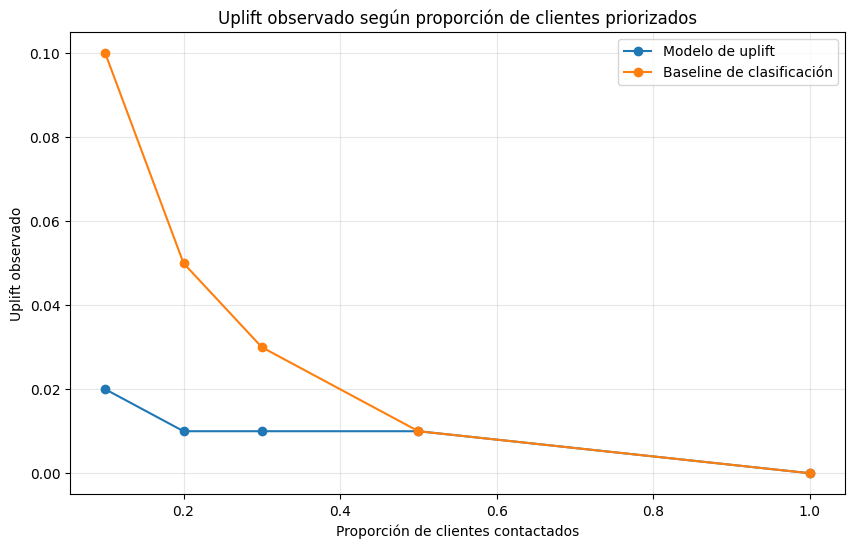

In [94]:
plt.figure(figsize=(10, 6))
plt.plot(
    comparacion_targeting['proporcion'],
    comparacion_targeting['uplift_observado_uplift'],
    marker='o',
    label='Modelo de uplift'
)

plt.plot(
    comparacion_targeting['proporcion'],
    comparacion_targeting['uplift_observado_baseline'],
    marker='o',
    label='Baseline de clasificación'
)

plt.title('Uplift observado según proporción de clientes priorizados')
plt.xlabel('Proporción de clientes contactados')
plt.ylabel('Uplift observado')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [95]:
resumen_metricas = pd.DataFrame({
    'modelo': ['Baseline de clasificación', 'Modelo de uplift'],
    'uplift_auc': [round(uplift_auc_baseline, 2), round(uplift_auc_modelo, 2)],
    'qini_auc': [round(qini_baseline, 2), round(qini_modelo, 2)]
})

resumen_metricas

,modelo,uplift_auc,qini_auc
0,Baseline de clasificación,0.03,0.51
1,Modelo de uplift,0.00,0.07


In [96]:
tabla_resumen = comparacion_targeting.copy()

tabla_resumen = tabla_resumen[[
    'proporcion',
    'clientes_uplift',
    'uplift_observado_uplift',
    'uplift_observado_baseline'
]].rename(columns={
    'clientes_uplift': 'clientes_priorizados',
    'uplift_observado_uplift': 'uplift_observado_modelo_uplift',
    'uplift_observado_baseline': 'uplift_observado_baseline'
})

tabla_resumen

,proporcion,clientes_priorizados,uplift_observado_modelo_uplift,uplift_observado_baseline
0,0.1,577,0.02,0.10
1,0.2,1154,0.01,0.05
2,0.3,1732,0.01,0.03
3,0.5,2887,0.01,0.01
4,1.0,5774,0.00,0.00


In [97]:
ruta_metricas = r"C:\Users\sebas\OneDrive\Desktop\Proyecto Chatbot\Opti-Correos\resumen_metricas_uplift.csv"
ruta_targeting = r"C:\Users\sebas\OneDrive\Desktop\Proyecto Chatbot\Opti-Correos\comparacion_targeting.csv"
ruta_tabla_resumen = r"C:\Users\sebas\OneDrive\Desktop\Proyecto Chatbot\Opti-Correos\tabla_resumen_evaluacion.csv"

resumen_metricas.to_csv(ruta_metricas, index=False)
comparacion_targeting.to_csv(ruta_targeting, index=False)
tabla_resumen.to_csv(ruta_tabla_resumen, index=False)

In [98]:
mejor_qini = 'Modelo de uplift' if qini_modelo > qini_baseline else 'Baseline de clasificación'
mejor_uplift_auc = 'Modelo de uplift' if uplift_auc_modelo > uplift_auc_baseline else 'Baseline de clasificación'

print("Mejor modelo según Qini AUC:", mejor_qini)
print("Mejor modelo según Uplift AUC:", mejor_uplift_auc)

Mejor modelo según Qini AUC: Baseline de clasificación
Mejor modelo según Uplift AUC: Baseline de clasificación


## Resultados de la evaluación

- El modelo de uplift fue evaluado con métricas adecuadas para problemas de impacto incremental.
- La curva de uplift y la curva Qini permiten analizar si el ranking del modelo prioriza correctamente a los clientes con mayor efecto incremental esperado.
- El uso de `id_cliente` permitió asegurar que la comparación entre baseline y modelo de uplift se realizara sobre exactamente los mismos clientes.

## Hallazgo clave

Si el modelo de uplift supera al baseline en Uplift AUC, Qini AUC y uplift observado en los segmentos priorizados, entonces existe evidencia de que ordenar clientes por uplift estimado es mejor estrategia que ordenarlos solo por probabilidad de conversión.

## Implicación para negocio

Esto significa que el modelo no solo predice mejor, sino que ayuda a tomar mejores decisiones de targeting, maximizando impacto incremental en campañas.